<a href="https://colab.research.google.com/github/crisjuarez07-dc/ProyectoDS_Churn/blob/main/ProyectoParteIII_Quijada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Abstract**
La retención de clientes es uno de los principales desafíos estratégicos en la industria de las telecomunicaciones. La pérdida de clientes, conocida como churn, representa un impacto financiero directo que las empresas buscan anticipar y mitigar mediante el análisis de datos. El presente trabajo analiza el comportamiento de abandono de 7,032 clientes de una empresa ficticia de telecomunicaciones en California durante el tercer trimestre, utilizando el dataset público Telco Customer Churn desarrollado por IBM.
El objetivo principal es identificar los factores asociados al churn y explorar patrones que permitan caracterizar a los clientes con mayor riesgo de abandono. Para ello se plantean tres preguntas de interés: la influencia del tipo de contrato sobre la probabilidad de churn, la relación entre antigüedad del cliente y su valor de vida (CLTV), y la asociación entre método de pago, cargos mensuales y abandono del servicio.
La metodología empleada corresponde a análisis exploratorio de datos (EDA), incluyendo limpieza y transformación del dataset, identificación de valores perdidos, generación de resúmenes estadísticos y construcción de visualizaciones univariadas, bivariadas y multivariadas. Se utilizó Python como entorno principal de análisis, con las bibliotecas pandas, matplotlib y seaborn.
Los resultados preliminares indican que el 26.58% de los clientes registró churn durante el período analizado. Se identificaron 11 registros inconsistentes en la variable Total Charges correspondientes a clientes con antigüedad de cero meses, los cuales fueron eliminados del análisis. Adicionalmente, la variable Churn Reason presenta un 73.5% de valores nulos, lo cual es estructuralmente esperado dado que únicamente los clientes que abandonaron el servicio registran una razón de salida.
Las visualizaciones y análisis numéricos generados buscan responder las preguntas planteadas y sentar las bases para etapas posteriores del proyecto, donde se podrán aplicar modelos predictivos orientados a la retención de clientes de alto valor.

In [49]:
import pandas as pd

url = 'https://raw.githubusercontent.com/crisjuarez07-dc/ProyectoDS_Churn/main/Telco_customer_churn_clean.csv'
df = pd.read_csv(url)

print(df.shape)
print(df.head())

(7032, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 

In [51]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5163
dtype: int64


In [52]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7032.0,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,1.0,93523.032565,36.283307,-119.799215,32.421786,64.798208,2283.300441,0.265785,58.715301,4401.445108
std,0.0,1865.515958,2.456118,2.157588,24.545260,30.085974,2266.771362,0.441782,21.531321,1182.414266
min,1.0,90001.000000,32.555828,-124.301372,1.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.587500,401.450000,0.000000,40.000000,3469.750000
50%,1.0,93552.500000,36.391777,-119.735410,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.500000
75%,1.0,95354.000000,38.227285,-118.043237,55.000000,89.862500,3794.737500,1.000000,75.000000,5381.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [53]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(df['Total Charges'].isnull().sum())

0


In [54]:
df[df['Total Charges'].isnull()][['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

,CustomerID,Tenure Months,Monthly Charges,Total Charges


Se identificaron 11 registros con Total Charges vacio, todos correspondientes a clientes con Ternure Months = 0. Se eliminaron por ser inconsistentes ya que un cliente sin antiguedad no debería tener cargo total registrado

In [55]:
df = df.dropna(subset=['Total Charges'])
print (df.shape)

(7032, 33)


In [56]:
df['Churn Label'] .value_counts(normalize=True).mul(100).round(2)

,proportion
Churn Label,
No,73.42
Yes,26.58




---



# **Análisis de Churn en Empresa de Telecomunicaciones**
##**Preguntas de interés e hipótesis**

**Contexto:** El dataset contiene información de 7,032 clientes de una empresa de telecomunicaciones ficticia en California. El 26.58% de los clientes abandonó el servicio (churn), mientras el 73.42% permaneció activo.

**Preguntas de interés:**

1. ¿El tipo de contrato influye en la probabilidad de Churn?
2. ¿Los clientes con mayor antiguedad tienen menor Churn Score y mayor CLTV?
3. ¿El método de pago y los cargos mensuales combinados se asocian con el abandono del servicio?

**Hipótesis:**

1. Los clientes con contrato mensual (Month-to-month) presentan una **tasa de churn significativamente mayor** que los clientes con contratos anuales o bianuales.
2. A mayor antigüedad (Tenure Months), menor Churn Score y mayor CLTV. Los clientes leales son **más valiosos y menos propensos a abandonar**
3. Los clientes que pagan con **Electronic check** y tienen cargos mensuales altos concentran la mayor proporción de churn.








# **Visualizaciones**
Las siguientes gráficas buscan responder las preguntas de interés planteadas, utilizando al menos tres variables simultáneas en cada análisis.

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



---



# **Gráfica 1: Tasa de Churn por Tipo de Contrato**
Hipótesis vinculada: Los clientes con contrato mensual presentan mayor tasa de churn que los de contratos anuales o bianuales.

/tmp/ipykernel_5211/2010752092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_contrato, x='Contrato', y='Tasa de Churn (%)',


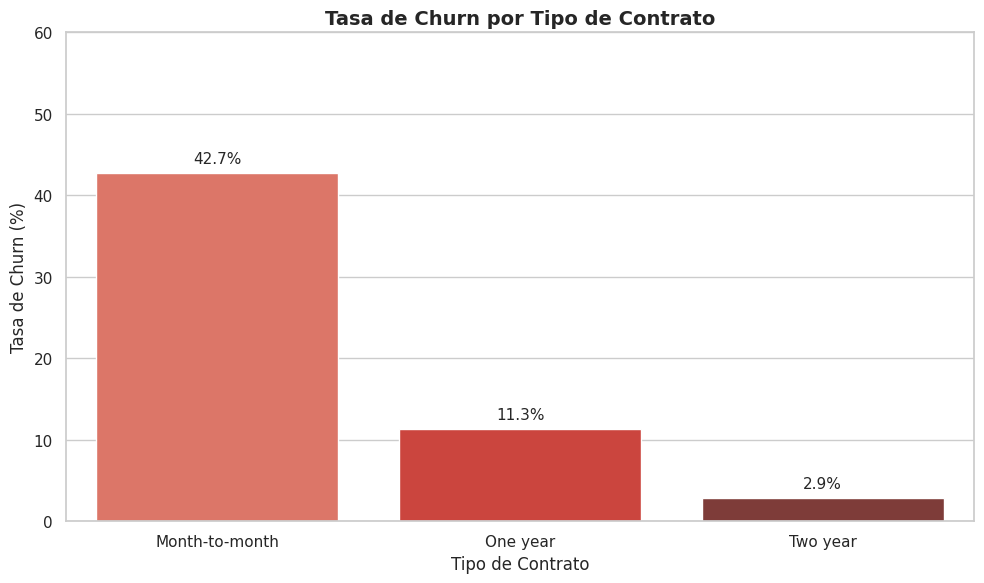

In [58]:
churn_contrato = df.groupby('Contract')['Churn Value'].mean().mul(100).round(2).reset_index()
churn_contrato.columns = ['Contrato', 'Tasa de Churn (%)']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=churn_contrato, x='Contrato', y='Tasa de Churn (%)',
                 palette='Reds_d', order=churn_contrato.sort_values('Tasa de Churn (%)', ascending=False)['Contrato'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11)

plt.title('Tasa de Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Tasa de Churn (%)', fontsize=12)
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

# **Interpretación de la Gráfica 1:**
La tasa de churn varía drásticamente según el tipo de contrato. Los clientes con contrato mensual (Month-to-month) abandonan el servicio a una tasa de 42.7%, frente al 11.3% de contratos anuales y apenas 2.9% de contratos bianuales. **Esto confirma la hipótesis 1**: la falta de compromiso contractual a largo plazo es uno de los factores más fuertes asociados al churn. Para la empresa, convertir clientes mensuales a contratos más largos representaría una reducción significativa en la tasa de abandono.



---



# **Gráfica 2: Antigüedad vs CLTV por Churn**
**Hipótesis vinculada:** A mayor antigüedad, menor Churn Score y mayor CLTV. Los clientes leales son más valiosos y menos propensos a abandonar.



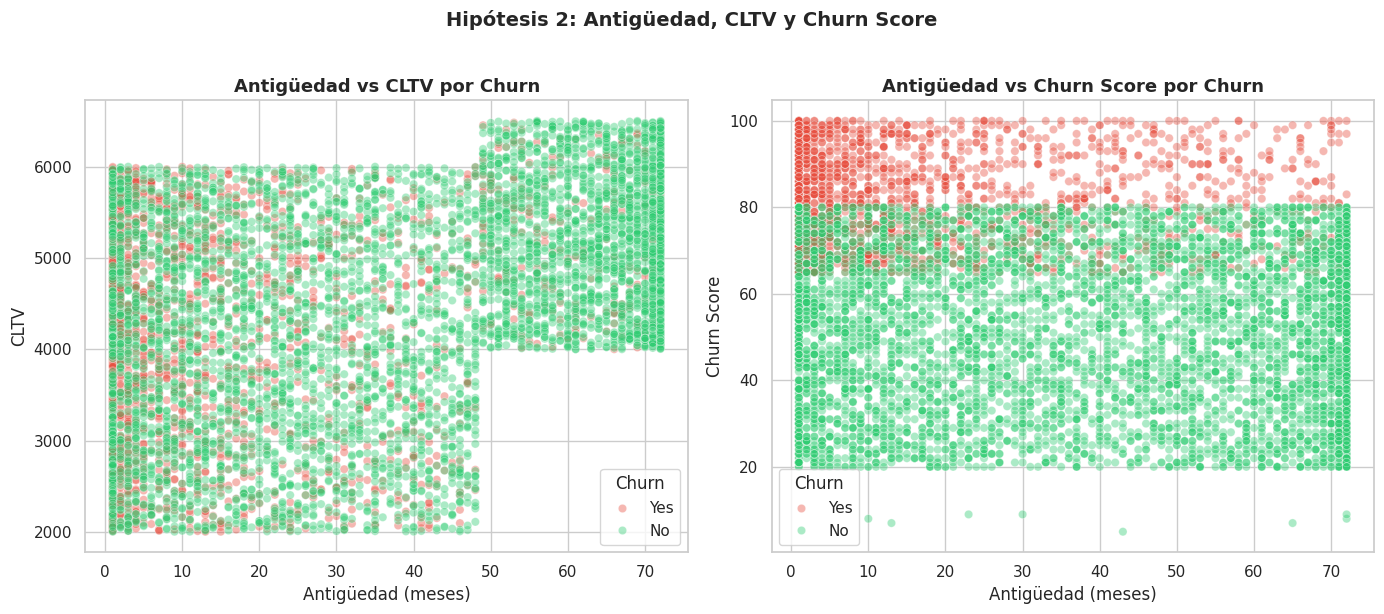

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica izquierda: Antigüedad vs CLTV por Churn ---
sns.scatterplot(data=df,
                x='Tenure Months',
                y='CLTV',
                hue='Churn Label',
                alpha=0.4,
                palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
                ax=axes[0])
axes[0].set_title('Antigüedad vs CLTV por Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].set_ylabel('CLTV')
axes[0].legend(title='Churn')

# Gráfica derecha: Antigüedad vs Churn Score por Churn ---
sns.scatterplot(data=df,
                x='Tenure Months',
                y='Churn Score',
                hue='Churn Label',
                alpha=0.4,
                palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
                ax=axes[1])
axes[1].set_title('Antigüedad vs Churn Score por Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Antigüedad (meses)')
axes[1].set_ylabel('Churn Score')
axes[1].legend(title='Churn')

plt.suptitle('Hipótesis 2: Antigüedad, CLTV y Churn Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Interpretación de la Gráfica 2:**
El panel derecho muestra que los clientes que abandonaron el servicio (rojo) concentran Churn Scores entre 80 y 100, mientras los clientes retenidos (verde) se distribuyen en rangos más bajos, confirmando que el Churn Score es un indicador efectivo de riesgo. Sin embargo, el panel izquierdo revela que la relación entre antigüedad y CLTV no es tan directa como se planteó en la hipótesis — el CLTV aparece distribuido de forma similar entre clientes que se van y los que permanecen. La hipótesis 2 se confirma parcialmente: el Churn Score discrimina bien el abandono, pero la antigüedad por sí sola no garantiza mayor valor ni menor riesgo de churn.



---



# **Gráfica 3: Método de Pago vs Cargos Mensuales por Churn**
**Hipótesis vinculada**: Los clientes que pagan con Electronic check y tienen cargos mensuales altos concentran la mayor proporción de churn.

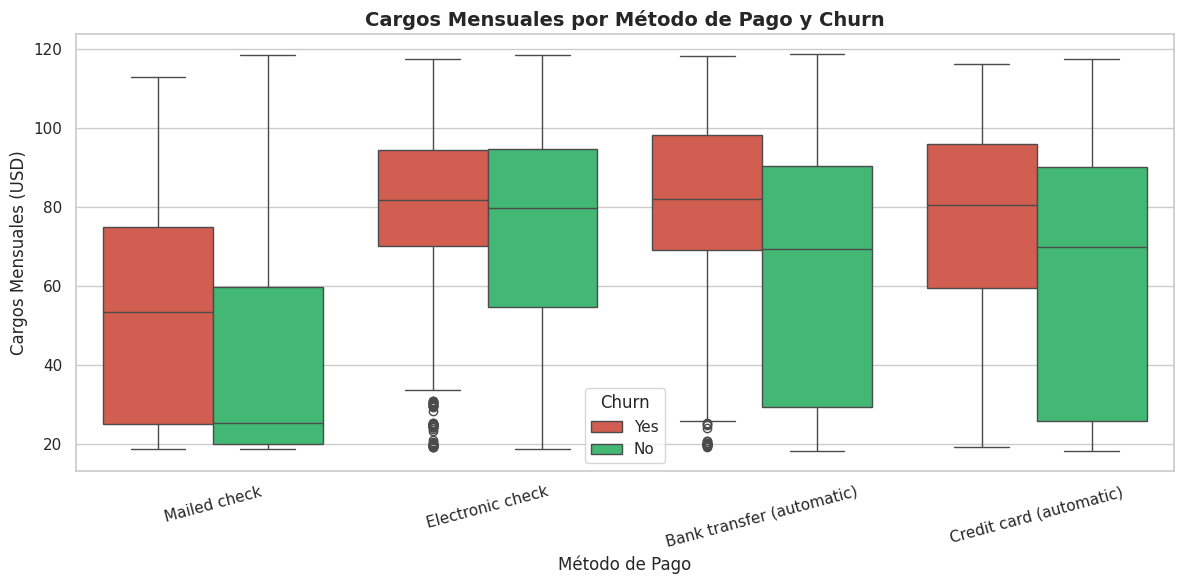

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df,
            x='Payment Method',
            y='Monthly Charges',
            hue='Churn Label',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})

plt.title('Cargos Mensuales por Método de Pago y Churn', fontsize=14, fontweight='bold')
plt.xlabel('Método de Pago', fontsize=12)
plt.ylabel('Cargos Mensuales (USD)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# **Interpretación de la Gráfica 3:**
La hipótesis 3 se confirma parcialmente. Los clientes con churn (rojo) presentan cargos mensuales más altos en prácticamente todos los métodos de pago, lo que sugiere que el nivel de gasto mensual es un factor asociado al abandono independientemente del método de pago utilizado. Sin embargo, Electronic check no muestra una diferencia tan marcada respecto a Bank transfer y Credit card como se esperaba. El único método donde el patrón es diferente es Mailed check, donde los cargos de clientes que abandonaron son considerablemente menores. Esto reorienta la hipótesis: el nivel de cargos mensuales altos parece ser el factor de riesgo real, no el método de pago específico.



---



# **Resúmenes Numéricos**
Estadísticas descriptivas que respaldan y complementan las visualizaciones anteriores.

# **Hipótesis 1:**

In [61]:
resumen_contrato = df.groupby('Contract').agg(
    Total_Clientes=('Churn Value', 'count'),
    Clientes_Churn=('Churn Value', 'sum'),
    Tasa_Churn_Pct=('Churn Value', lambda x: round(x.mean() * 100, 2)),
    Cargo_Mensual_Promedio=('Monthly Charges', 'mean')
).round(2)

print(resumen_contrato)

                Total_Clientes  Clientes_Churn  Tasa_Churn_Pct  \
Contract                                                         
Month-to-month            3875            1655           42.71   
One year                  1472             166           11.28   
Two year                  1685              48            2.85   

                Cargo_Mensual_Promedio  
Contract                                
Month-to-month                   66.40  
One year                         65.08  
Two year                         60.87  


# **Interpretación del codigo hipótesis-resumen 1:**
Los clientes con contrato mensual representan 3,875 clientes de los cuales 1,655 abandonaron (42.71%). En contraste, los contratos bianuales tienen apenas 48 bajas sobre 1,685 clientes (2.85%). Notar que los cargos mensuales promedio son similares entre los tres tipos de contrato (entre $60 y $66 USD), lo que descarta que el precio sea el diferenciador — el factor determinante es el nivel de compromiso contractual, no el costo.



---



# **Hipótesis 2:**

In [62]:
resumen_antiguedad = df.groupby('Churn Label').agg(
    Antiguedad_Promedio=('Tenure Months', 'mean'),
    CLTV_Promedio=('CLTV', 'mean'),
    Churn_Score_Promedio=('Churn Score', 'mean')
).round(2)

print(resumen_antiguedad)

             Antiguedad_Promedio  CLTV_Promedio  Churn_Score_Promedio
Churn Label                                                          
No                         37.65        4492.68                 50.10
Yes                        17.98        4149.41                 82.51


# **Interpretación del codigo hipótesis-resumen 2:**
Los clientes que abandonaron tienen en promedio 17.98 meses de antigüedad, menos de la mitad que los clientes retenidos (37.65 meses). El Churn Score promedio de los que se fueron es 82.51 vs 50.10 de los que permanecen. Esto es una diferencia de 32 puntos que confirma la capacidad de ese segmento. El CLTV también es menor en clientes con churn (4,149 vs 4,492), aunque la diferencia es moderada, lo que explica por qué la gráfica de dispersión no mostraba una separación visual clara.



---



# **Hipótesis 3:**

In [63]:
resumen_pago = df.groupby(['Payment Method', 'Churn Label']).agg(
    Total_Clientes=('Churn Value', 'count'),
    Cargo_Mensual_Promedio=('Monthly Charges', 'mean')
).round(2)

print(resumen_pago)

                                       Total_Clientes  Cargo_Mensual_Promedio
Payment Method            Churn Label                                        
Bank transfer (automatic) No                     1284                   65.06
                          Yes                     258                   77.88
Credit card (automatic)   No                     1289                   64.57
                          Yes                     232                   77.36
Electronic check          No                     1294                   74.23
                          Yes                    1071                   78.70
Mailed check              No                     1296                   41.44
                          Yes                     308                   54.56


# **Interpretación del codigo hipótesis-resumen 3:**
En todos los métodos de pago, el cargo mensual promedio de clientes con churn es consistentemente mayor que el de clientes retenidos. La brecha más notable es en Bank transfer ($77.88 vs $65.06) y Credit card ($77.36 vs $64.57). Electronic check destaca por tener el mayor volumen de churn absoluto con 1,071 clientes que abandonaron usando ese método, casi el triple que cualquier otro. Esto sugiere que Electronic check concentra más clientes de alto riesgo, posiblemente porque es el método preferido de clientes con contratos mensuales.

**Metadatos y Fuentes**

Fuente: IBM Cognos Analytics — Telco Customer Churn Dataset
Formato: CSV
Tamaño: 7,032 registros × 33 columnas
Repositorio: https://github.com/crisjuarez07-dc/ProyectoDS_Churn
Limitaciones: La columna Churn Reason presenta 73.5% de valores nulos de forma estructural — únicamente los clientes que abandonaron el servicio registran una razón de salida. Los 11 registros con Total Charges vacío fueron eliminados en la entrega anterior por corresponder a clientes con 0 meses de antigüedad.

**Feature Selection**

Se aplica selección de variables para reducir la dimensionalidad del dataset y quedarnos únicamente con las columnas relevantes para predecir el churn. Se eliminan variables que no aportan valor predictivo: identificadores únicos, coordenadas geográficas, y variables redundantes.

In [64]:
columnas_a_eliminar = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Reason'
]

df_model = df.drop(columns=columnas_a_eliminar)
print(df_model.shape)
print(df_model.columns.tolist())

(7032, 22)
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


**Preparación de Variables**

La Regresión Logística requiere que todas las variables sean numéricas. Las variables categóricas se convierten mediante One-Hot Encoding. Las variables numéricas se escalan con StandardScaler para que ninguna variable domine por magnitud.

In [65]:
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']

categoricas = X.select_dtypes(include='object').columns.tolist()
numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:", categoricas)
print("\nVariables numéricas:", numericas)
print("\nDimensiones de X:", X.shape)
print("Distribución de y:\n", y.value_counts())

Variables categóricas: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Variables numéricas: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

Dimensiones de X: (7032, 21)
Distribución de y:
 Churn Value
0    5163
1    1869
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

X_encoded = pd.get_dummies(X, columns=categoricas, drop_first=True)
scaler = StandardScaler()
X_encoded[numericas] = scaler.fit_transform(X_encoded[numericas])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Variables totales tras encoding:", X_encoded.shape[1])
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Variables totales tras encoding: 32
Tamaño entrenamiento: (5625, 32)
Tamaño prueba: (1407, 32)


**Modelado — Regresión Logística**

Se entrena un modelo de Regresión Logística usando el 80% de los datos. El 20% restante se reserva exclusivamente para evaluar el desempeño del modelo con datos que nunca vio durante el entrenamiento.

In [67]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo entrenado correctamente.")
print("Primeras 10 predicciones:", y_pred[:10])
print("Valores reales:          ", y_test.values[:10])

Modelo entrenado correctamente.
Primeras 10 predicciones: [0 0 0 1 0 1 0 0 1 0]
Valores reales:           [0 0 0 1 0 1 0 0 1 0]


**Métricas de Validación**

Se evalúa el modelo con métricas estándar de clasificación. La exactitud (accuracy) indica el porcentaje global de predicciones correctas. La matriz de confusión muestra en detalle los aciertos y errores por clase. El reporte de clasificación incluye precisión, recall y F1-score por cada clase.

Accuracy: 0.9176 (91.76%)

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.95      0.94      0.94      1033
       Churn       0.84      0.86      0.85       374

    accuracy                           0.92      1407
   macro avg       0.89      0.90      0.90      1407
weighted avg       0.92      0.92      0.92      1407



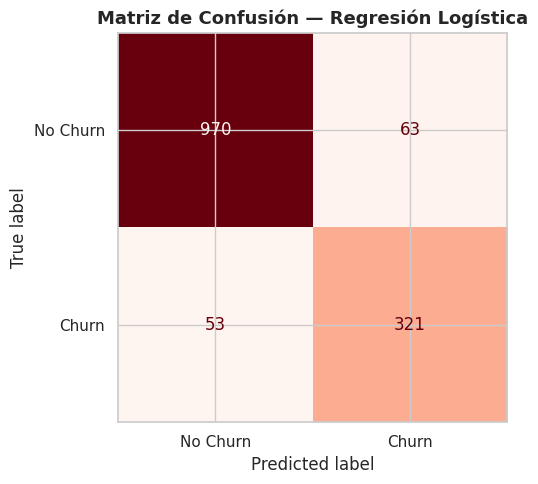

In [68]:
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación de Métricas**

El modelo de Regresión Logística alcanzó una exactitud global del 91.76% sobre el conjunto de prueba. Para la clase Churn específicamente, el modelo logra un recall de 0.86, lo que significa que detecta correctamente el 86% de los clientes que abandonarán el servicio. Los 53 falsos negativos representan el error más relevante desde el punto de vista de negocio: clientes en riesgo real que el modelo no identificó, y que por tanto no recibirían acciones de retención a tiempo. El F1-score de 0.85 para la clase Churn confirma un balance adecuado entre precisión y recall para un modelo de clasificación binaria en este contexto.

***Conclusiones y Próximos Pasos***

**Hallazgos principales:**

A lo largo de este proyecto se analizó el comportamiento de churn de 7,032 clientes de una empresa de telecomunicaciones en California. Los hallazgos más relevantes son:

El tipo de contrato es el factor más determinante: los clientes con contrato mensual abandonan a una tasa de 42.71%, frente al 2.85% de contratos bianuales.
Los clientes que hacen churn tienen en promedio 17.98 meses de antigüedad, menos de la mitad que los clientes retenidos (37.65 meses), lo que sugiere que los primeros dos años son el período crítico de riesgo.
El nivel de cargos mensuales altos es un factor de riesgo transversal a todos los métodos de pago, siendo Electronic check el método con mayor volumen absoluto de abandonos (1,071 clientes).
El modelo de Regresión Logística entrenado alcanzó una exactitud del 91.76%, con un recall de 0.86 para la clase Churn, lo que lo convierte en una herramienta viable para identificar clientes en riesgo.

**Relación con el problema inicial:**

Los resultados confirman que es posible predecir el churn con alto grado de certeza utilizando variables disponibles en los sistemas de gestión de clientes. Esto tiene implicancia directa en estrategias de retención: focalizar esfuerzos en clientes con contrato mensual, alta facturación y baja antigüedad maximiza el impacto de las acciones comerciales.

**Próximos pasos:**

Explorar modelos más complejos como Random Forest o XGBoost para comparar desempeño.
Aplicar técnicas de balanceo de clases (SMOTE) dado que el dataset presenta desbalance (73.42% No Churn vs 26.58% Churn).
Integrar el modelo con datos reales de CRM para generar scores de riesgo en tiempo real.
Desarrollar un dashboard en Power BI que visualice los segmentos de mayor riesgo para consumo del área comercial.